In [1]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, r2_score, root_mean_squared_error, mean_absolute_error, balanced_accuracy_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.utils.class_weight import compute_sample_weight
from utils import load_plastchem, calculate_mfps
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.decomposition import PCA
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import StratifiedKFold, HalvingGridSearchCV, GridSearchCV
from xgboost import XGBClassifier
import pandas as pd
from collections import Counter

In [2]:
# Data preparation
plast_chem, pcc = load_plastchem(Path.cwd() / "data" / "plastchem_db_v1.0.tsv")

hazard_cols = [
        'Hazard_information_Carcinogenic', 'Hazard_information_Mutagenic', 'Hazard_information_Reproduction', 'Hazard_information_CMR', 'Hazard_information_STOT',
        'Hazard_information_EDC', 'Hazard_information_Aquatic_toxicity', 'Hazard_information_PBT', 'Hazard_information_vPvB', 'Hazard_information_PMT', 'Hazard_information_vPvM'
    ]

# exclude NAs
plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
plast_chem_hazard = plast_chem_hazard.where(plast_chem_hazard['Hazard_information_Toxicity_score'] != 0.25)

# include NAs → test for sparsity algo
#plast_chem_hazard = plast_chem[plast_chem[hazard_cols].notna().any(axis=1)]
#plast_chem_hazard = plast_chem.where(plast_chem['Hazard_information_Toxicity_score'] != 0.25)

print(plast_chem_hazard['Hazard_information_Hazard_score'].value_counts())

# fingerprints
fps = calculate_mfps(plast_chem_hazard, 'Properties_isomeric_smiles')

mask = [fp is not None for fp in fps]
plast_chem_hazard = plast_chem_hazard[mask].copy()
fps = [fp for fp in fps if fp is not None]

X = np.vstack(fps)

Hazard_information_Hazard_score
2.0    3049
0.5    1188
1.0    1041
0.0     161
Name: count, dtype: int64


[16:19:01] WARNING: not removing hydrogen atom without neighbors
[16:19:01] WARNING: not removing hydrogen atom without neighbors
[16:19:01] WARNING: not removing hydrogen atom without neighbors
[16:19:01] WARNING: not removing hydrogen atom without neighbors
[16:19:01] WARNING: not removing hydrogen atom without neighbors
[16:19:01] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] WARNING: not removing hydrogen atom without neighbors
[16:19:02] Explicit valen

## binary
- focus on binary, multiclass as extension

In [3]:
# less hazardous and hazardous 1 and 2 get same category
y = plast_chem_hazard['Hazard_information_Hazard_score'].replace(0.5,1).replace(2,1).replace(3,1)
X = X.copy()
print(y.value_counts(normalize=True))

Hazard_information_Hazard_score
1.0    0.967144
0.0    0.032856
Name: proportion, dtype: float64


In [4]:
# splitting
X_exploration, X_split, y_exploration, y_split = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_split, y_split, test_size=0.5, stratify=y_split, random_state=42)

### Training

In [6]:
pipeline = Pipeline([
    # PCA for dimensionality reduction
    ("pca", PCA(random_state=0)),
    # Undersample majority based on edited NN
    ("enn", EditedNearestNeighbours()),
    # Oversample minority using SMOTE
    ("smote", SMOTE(random_state=0)),
    # train xgboost
    ("clf", XGBClassifier(tree_method="hist", random_state=0, n_jobs=-1, max_delta_step=3))
])
param_grid = {
    "pca__n_components": [50, 60, 70],
    "clf__max_depth": [5, 7, 9],
    "clf__learning_rate": [0.0001, 0.001, 0.01, 0.1],
    "clf__n_estimators": [100, 150, 200]
}
# set n_jobs to 1 here, let xgboost handle parallelization
# halving grid search not possible because data during PCA is not enough
search = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=0),
    scoring="balanced_accuracy",
    verbose=10,
    n_jobs=1
)


In [7]:
%%time
search.fit(X_exploration, y_exploration)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5; 1/108] START clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50
[CV 1/5; 1/108] END clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50;, score=0.543 total time=   0.6s
[CV 2/5; 1/108] START clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50
[CV 2/5; 1/108] END clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50;, score=0.697 total time=   0.6s
[CV 3/5; 1/108] START clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50
[CV 3/5; 1/108] END clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50;, score=0.570 total time=   0.6s
[CV 4/5; 1/108] START clf__learning_rate=0.0001, clf__max_depth=5, clf__n_estimators=100, pca__n_components=50
[CV 4/5; 1/108] END clf__learning_rate=0.0001, clf__max_depth=5, cl

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__learning_rate': [0.0001, 0.001, ...], 'clf__max_depth': [5, 7, ...], 'clf__n_estimators': [100, 150, ...], 'pca__n_components': [50, 60, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to 

In [31]:
print("Best parameter (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)

Best parameter (CV score=0.610):
{'clf__learning_rate': 0.0001, 'clf__max_depth': 9, 'clf__n_estimators': 200, 'pca__n_components': 110, 'smote__sampling_strategy': 1.0}


## Testing

In [32]:
# make predictions
best_model = search.best_estimator_
preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)
print(balanced_accuracy_score(y_test, preds))
print(classification_report(y_test, preds))
print(roc_auc_score(y_test, probs[:, 1]))

0.578058938600366
              precision    recall  f1-score   support

         0.0       0.05      0.43      0.09        23
         1.0       0.97      0.72      0.83       689

    accuracy                           0.71       712
   macro avg       0.51      0.58      0.46       712
weighted avg       0.94      0.71      0.81       712

0.5372310216444753


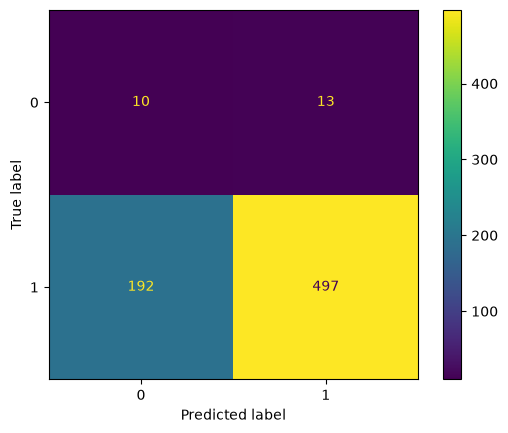

In [33]:
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [34]:
i = search.best_index_
print(search.cv_results_['std_test_score'][i], search.cv_results_['mean_test_score'][i])

0.05723013657011584 0.6102174374416056


In [35]:
pca = best_model.named_steps["pca"]
print(pca.explained_variance_ratio_.sum())

0.5627394962086933


### Baseline (Dummy Classifier)

In [36]:
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_exploration, y_exploration)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'stratified'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.03,0.97]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[float64](2,)","[0.,1.]"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,2048
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [37]:
# make predictions
dummy_preds = dummy.predict(X_test)
dummy_probs = dummy.predict_proba(X_test)
print(balanced_accuracy_score(y_test, dummy_preds))
print(classification_report(y_test, dummy_preds))
print(roc_auc_score(y_test, dummy_probs[:, 1]))

0.4818577648766328
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        23
         1.0       0.97      0.96      0.97       689

    accuracy                           0.93       712
   macro avg       0.48      0.48      0.48       712
weighted avg       0.94      0.93      0.93       712

0.4818577648766328


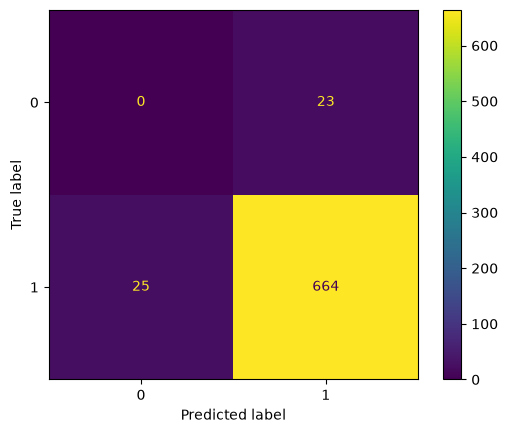

In [38]:
cm = confusion_matrix(y_test, dummy_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()
# mainly guesses toxic

## Visual

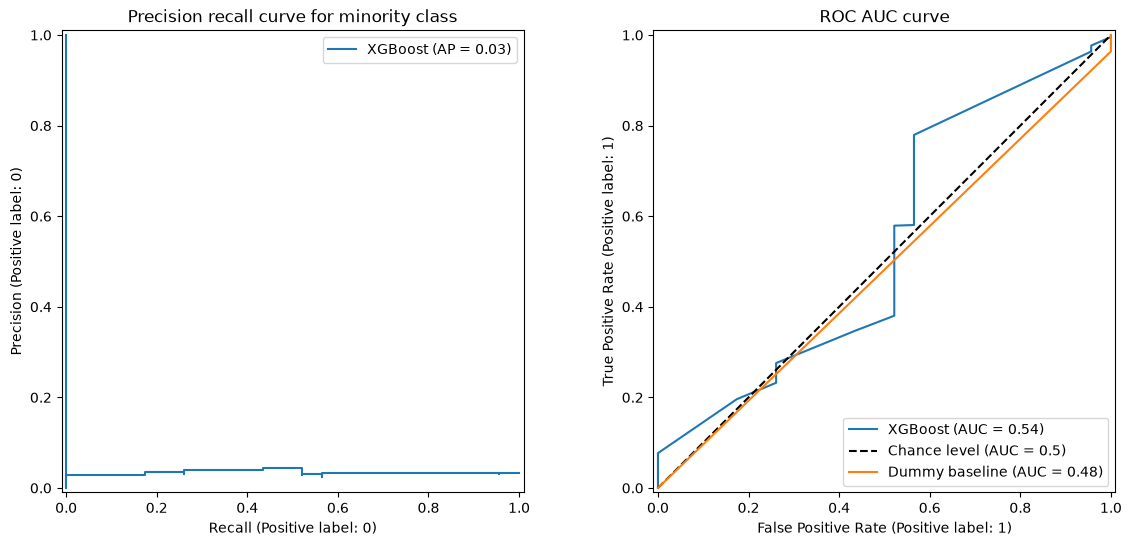

In [40]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
# Precision Recall plot
PrecisionRecallDisplay.from_predictions(y_test, probs[:, 1], pos_label=0, name="XGBoost", ax=axs[0])
axs[0].set_title("Precision recall curve for minority class")
# ROC_AUC baseline vs model for best estimator

RocCurveDisplay.from_predictions(y_test, probs[:, 1], name="XGBoost", ax=axs[1], plot_chance_level=True)
RocCurveDisplay.from_predictions(y_test, dummy_probs[:, 1], name="Dummy baseline", ax=axs[1])
axs[0].legend()
axs[1].set_title("ROC AUC curve")
plt.savefig(Path.cwd() / "roc_auc.svg", bbox_inches="tight")

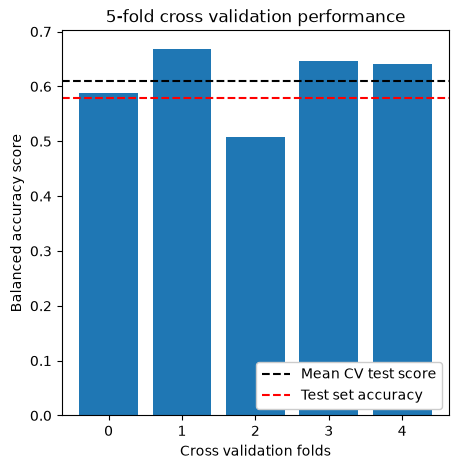

In [41]:
# CV Performance
best_idx = search.best_index_
fold_scores = [search.cv_results_[f"split{i}_test_score"][best_idx] for i in range(5)]

fig, ax = plt.subplots(figsize=(5,5))
ax.bar(range(5), fold_scores)
ax.axhline(search.cv_results_["mean_test_score"][best_idx], color="k", ls="--", label="Mean CV test score")
ax.axhline(balanced_accuracy_score(y_test, preds), color="r", ls="--", label="Test set accuracy")
ax.set_xlabel("Cross validation folds")
ax.set_ylabel("Balanced accuracy score")
ax.legend(loc="lower right", framealpha=1)
ax.set_title("5-fold cross validation performance")
plt.savefig("cv_performance.svg", bbox_inches="tight")

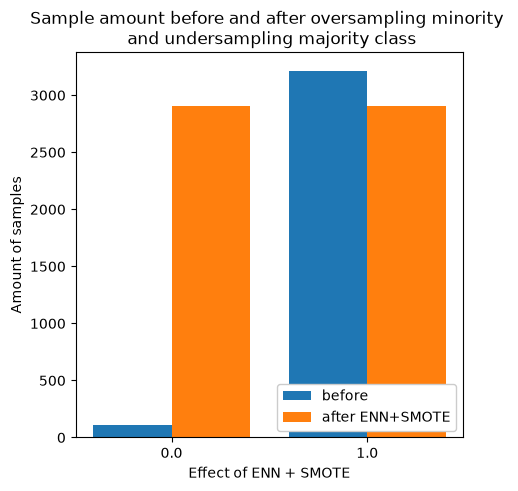

In [42]:
# SMOTE effect
before = Counter(y_exploration)
X_p = best_model.named_steps["pca"].fit_transform(X_exploration)
X_e, y_e = best_model.named_steps["enn"].fit_resample(X_p, y_exploration)
X_s, y_s = best_model.named_steps["smote"].fit_resample(X_e, y_e)
after = Counter(y_s)

labels = sorted(before)
fig, ax = plt.subplots(figsize=(5,5))
x = np.arange(len(labels))
ax.bar(x-0.2, [before[l] for l in labels], width=0.4, label="before")
ax.bar(x+0.2, [after[l] for l in labels], width=0.4, label="after ENN+SMOTE")
ax.set_xticks(x, labels)
ax.legend(loc="lower right", framealpha=1)
ax.set_xlabel("Effect of ENN + SMOTE")
ax.set_ylabel("Amount of samples")
ax.set_title("Sample amount before and after oversampling minority \n and undersampling majority class")
plt.savefig("smote_effect.svg", bbox_inches="tight")
# damn thats a lot of artificial samples